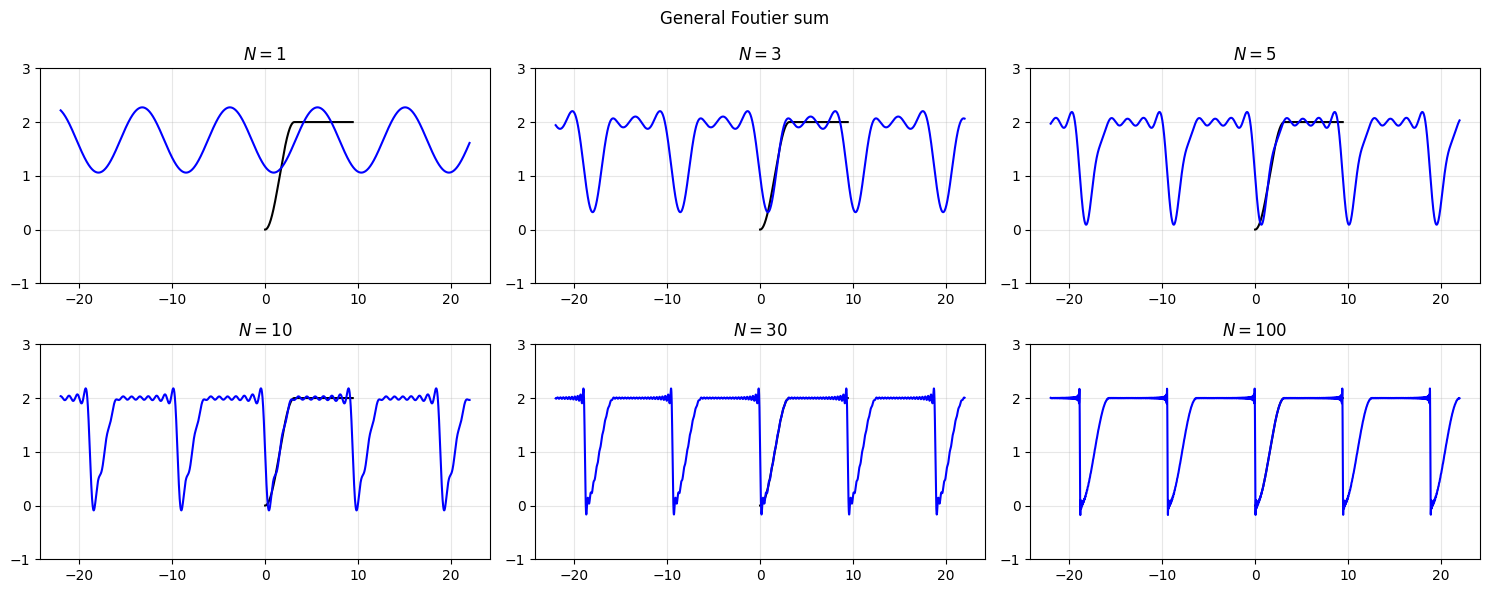

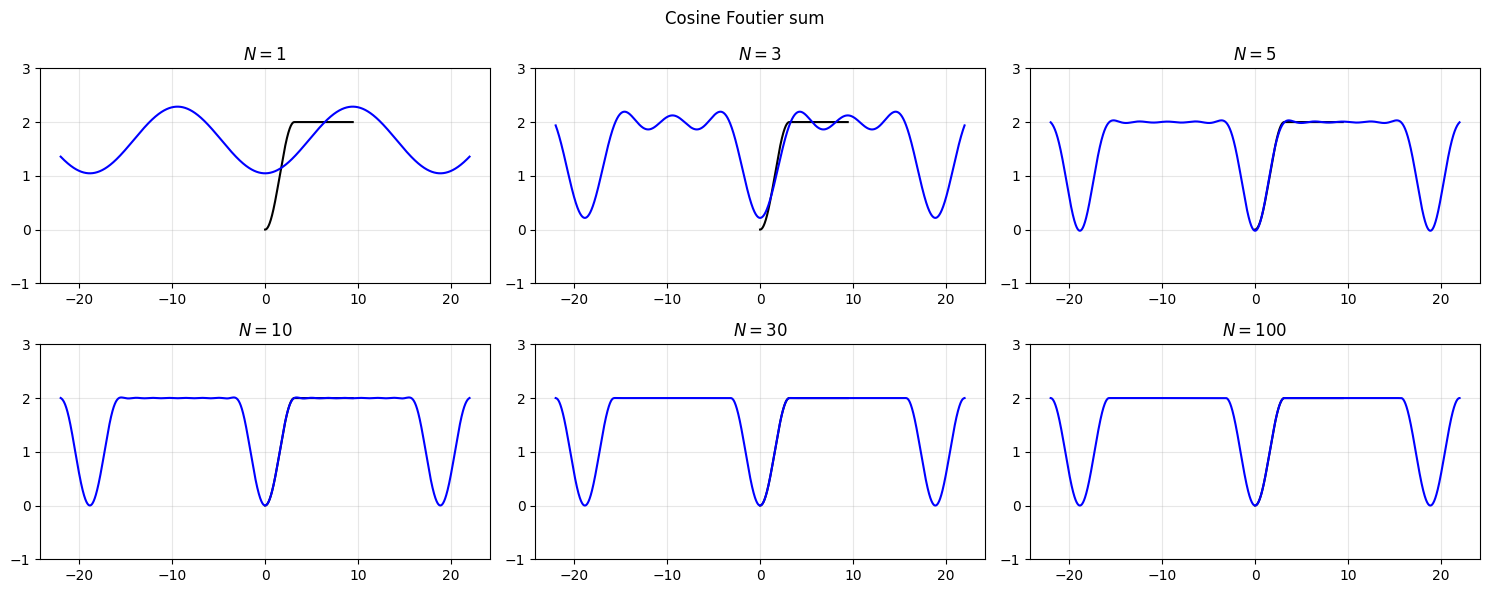

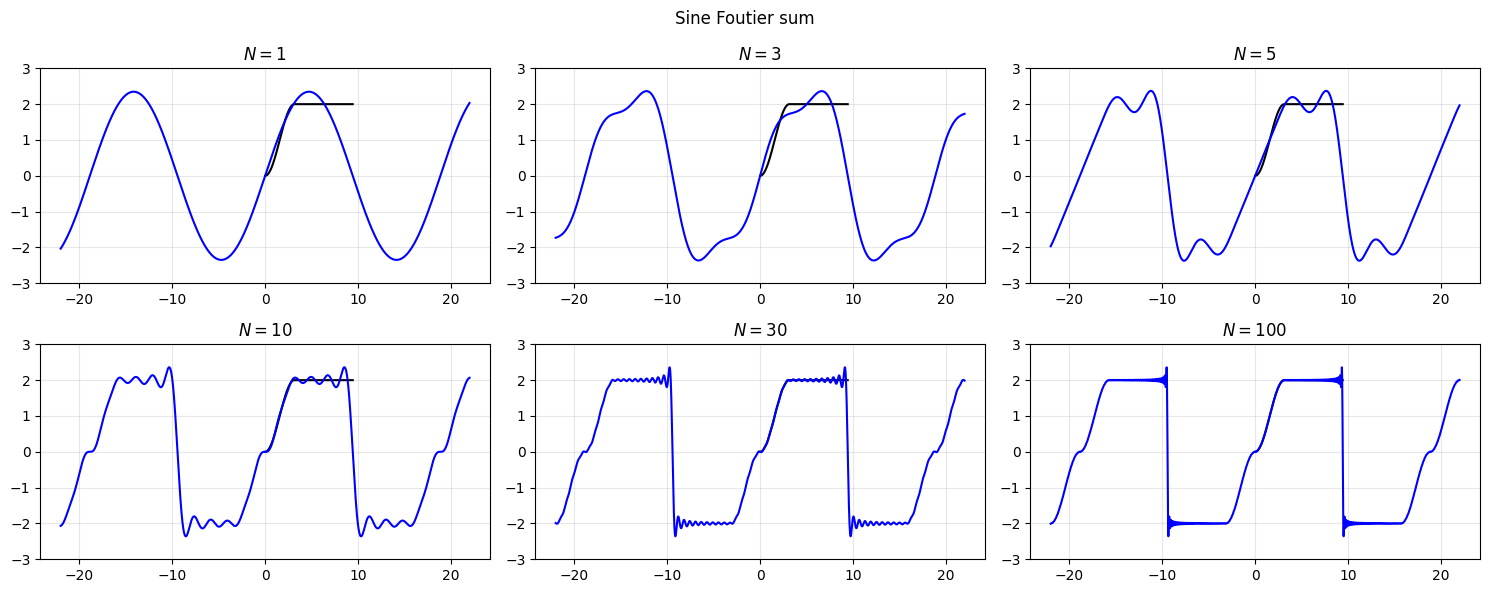

In [ ]:
import numpy as np
from numpy import pi
import pandas as pd
import matplotlib.pyplot as plt

# Вычисление f(x)
def f(x):
    return np.where(x < pi, 1 - np.cos(x), 2)

# Частичная сумма общего ряда Фурье
def S(x, N):
    res = 5/3
    for k in range(1, N + 1):
        c = 2*k*pi/3
        den = pi*k*(4*k*k - 9)
        arg = 2*k*x/3
        res += (((9 * np.sin(c) / den) * np.cos(arg)) +
                (((9 * (1 - np.cos(c)) - 8*k*k) / den) * np.sin(arg)))
    return res

# Частичная сумма ряда Фурье по косинусам
def E(x, N):
    res = 5/3
    for k in range(1, N+1):
        if k == 3:
            a = -1/3
        else:
            a =  (18 * np.sin(k*pi/3)) / (pi*k*(k*k - 9))
        res += a * np.cos(k*x/3)
    return res

# Частичная сумма ряда Фурье по синусам
def O(x, N):
    res = 0.0
    for k in range(1, N+1):
        if k == 3:
            b = 4/(3*np.pi)
        else:
            b = (((-(4*k*k - 36) * ((-1)**k)) - (18*np.cos(k*pi/3)) - 18) / 
                 (pi*k*(k*k - 9)))
        res += b * np.sin(k*x/3)
    return res

# Функция построения графиков частичных сумм для N = 1, 3, 5, 10, 30, 100 
def graphs(f_sum, title, is_positive=True):

    n_vals = [1, 3, 5, 10, 30, 100]
    x1 = np.linspace(0, 3*pi, 1000)
    x2 = np.linspace(-7*pi, 7*pi, 4000)
    fig, axes = plt.subplots(2, 3, figsize=(15, 6))
    axes = axes.flatten()
    fig.suptitle(title)

    for i in range(6):
        y = [f_sum(xi, n_vals[i]) for xi in x2]
        axes[i].set_title(rf'$N = {n_vals[i]}$')
        axes[i].plot(x1, f(x1), 'k')
        axes[i].plot(x2, y, 'b')
        if is_positive:
            axes[i].set_ylim(-1, 3)
        else:
            axes[i].set_ylim(-3, 3)
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

graphs(S, "General Fourier sum")
graphs(E, "Cosine Fourier sum")
graphs(O, "Sine Fourier sum", is_positive=False)
